# Elo Merchant Category Recommendation
## https://kaggle.com/competitions/elo-merchant-category-recommendation, 2018. Kaggle.

Планируемый пайплайн решения задачи:
1) EDA: подготовка данных, изучение признаков, агрегация признаков в historical_transactions и new_merchant_transactions по card_id. Merge таблиц в одну, с дальнейшим вычислением корреляции между признаками. Визуализация распределений, матрицы корреляций.
2) Feature Engineering: удаление шумовых признаков.
3) Baseline: в качестве бейзлайн планируется взять линейную регрессию с L1/L2 регуляризаторами на базовых признаках и сравнить их, затем постепенное добавление новых признаков (средняя сумма покупки, std покупки, месяц наибольшей активности, ..). Также стоит попробовать алгоритмы Random Forest, Extra Trees, XGBoost и LightGBM.
4) Продвинутые методы: стекинг из лучших моделей по результатам бейзлайн + попытка каскадирования моделей.

## 1. Загрузка данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train_df = pd.read_csv(r'data/train.csv')
test_df = pd.read_csv(r'data/test.csv')
history_df = pd.read_csv(r'data/historical_transactions.csv')
new_merch_df = pd.read_csv(r'data/new_merchant_transactions.csv')
merchants_df = pd.read_csv(r'data/merchants.csv')

In [4]:
train_df.info()
train_df.shape
train_df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 201917 entries, 0 to 201916
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   first_active_month  201917 non-null  str    
 1   card_id             201917 non-null  str    
 2   feature_1           201917 non-null  int64  
 3   feature_2           201917 non-null  int64  
 4   feature_3           201917 non-null  int64  
 5   target              201917 non-null  float64
dtypes: float64(1), int64(3), str(2)
memory usage: 13.5 MB


,first_active_month,card_id,feature_1,feature_2,feature_3,target
0,2017-06,C_ID_92a2005557,5,2,1,-0.820283
1,2017-01,C_ID_3d0044924f,4,1,0,0.392913
2,2016-08,C_ID_d639edf6cd,2,2,0,0.688056
3,2017-09,C_ID_186d6a6901,4,3,0,0.142495
4,2017-11,C_ID_cdbd2c0db2,1,3,0,-0.159749
5,2016-09,C_ID_0894217f2f,4,2,0,0.871585
6,2016-12,C_ID_7e63323c00,3,2,1,0.230129
7,2017-09,C_ID_dfa21fc124,3,2,1,2.135850
8,2017-08,C_ID_fe0fdac8ea,2,1,0,-0.065406
9,2016-08,C_ID_bf62c0b49d,2,2,0,0.300062


In [5]:
history_df.info()
history_df.head(15)

<class 'pandas.DataFrame'>
RangeIndex: 29112361 entries, 0 to 29112360
Data columns (total 14 columns):
 #   Column                Dtype  
---  ------                -----  
 0   authorized_flag       str    
 1   card_id               str    
 2   city_id               int64  
 3   category_1            str    
 4   installments          int64  
 5   category_3            str    
 6   merchant_category_id  int64  
 7   merchant_id           str    
 8   month_lag             int64  
 9   purchase_amount       float64
 10  purchase_date         str    
 11  category_2            float64
 12  state_id              int64  
 13  subsector_id          int64  
dtypes: float64(2), int64(6), str(6)
memory usage: 4.5 GB


,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id
0,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-8,-0.703331,2017-06-25 15:33:07,1.0,16,37
1,Y,C_ID_4e6213e9bc,88,N,0,A,367,M_ID_86ec983688,-7,-0.733128,2017-07-15 12:10:45,1.0,16,16
2,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_979ed661fc,-6,-0.720386,2017-08-09 22:04:29,1.0,16,37
3,Y,C_ID_4e6213e9bc,88,N,0,A,560,M_ID_e6d5ae8ea6,-5,-0.735352,2017-09-02 10:06:26,1.0,16,34
4,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-11,-0.722865,2017-03-10 01:14:19,1.0,16,37
5,Y,C_ID_4e6213e9bc,333,N,0,A,80,M_ID_50af771f8d,0,-0.734887,2018-02-24 08:45:05,1.0,9,37
6,Y,C_ID_4e6213e9bc,88,N,0,A,278,M_ID_5e8220e564,-11,-0.716855,2017-03-21 00:10:51,1.0,16,37
7,Y,C_ID_4e6213e9bc,3,N,0,A,80,M_ID_9d41786a50,-3,-0.657049,2017-11-18 20:05:55,1.0,16,37
8,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_979ed661fc,-8,-0.737967,2017-06-01 22:02:56,1.0,16,37
9,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_74ba14b5fc,-11,-0.715352,2017-03-16 15:41:22,1.0,16,37


In [6]:
new_merch_df.info()
new_merch_df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 1963031 entries, 0 to 1963030
Data columns (total 14 columns):
 #   Column                Dtype  
---  ------                -----  
 0   authorized_flag       str    
 1   card_id               str    
 2   city_id               int64  
 3   category_1            str    
 4   installments          int64  
 5   category_3            str    
 6   merchant_category_id  int64  
 7   merchant_id           str    
 8   month_lag             int64  
 9   purchase_amount       float64
 10  purchase_date         str    
 11  category_2            float64
 12  state_id              int64  
 13  subsector_id          int64  
dtypes: float64(2), int64(6), str(6)
memory usage: 307.1 MB


,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id
0,Y,C_ID_415bb3a509,107,N,1,B,307,M_ID_b0c793002c,1,-0.557574,2018-03-11 14:57:36,1.0,9,19
1,Y,C_ID_415bb3a509,140,N,1,B,307,M_ID_88920c89e8,1,-0.569580,2018-03-19 18:53:37,1.0,9,19
2,Y,C_ID_415bb3a509,330,N,1,B,507,M_ID_ad5237ef6b,2,-0.551037,2018-04-26 14:08:44,1.0,9,14
3,Y,C_ID_415bb3a509,-1,Y,1,B,661,M_ID_9e84cda3b1,1,-0.671925,2018-03-07 09:43:21,NaN,-1,8
4,Y,C_ID_ef55cf8d4b,-1,Y,1,B,166,M_ID_3c86fa3831,1,-0.659904,2018-03-22 21:07:53,NaN,-1,29
5,Y,C_ID_ef55cf8d4b,231,N,1,B,367,M_ID_8874615e00,2,-0.633007,2018-04-02 12:53:28,1.0,9,16
6,Y,C_ID_ef55cf8d4b,69,N,1,B,333,M_ID_6d061b5ddc,1,5.263697,2018-03-28 19:50:19,1.0,9,10
7,Y,C_ID_ef55cf8d4b,231,N,1,B,307,M_ID_df1e022f41,2,-0.553787,2018-04-05 08:06:52,1.0,9,19
8,Y,C_ID_ef55cf8d4b,69,N,1,B,278,M_ID_d15eae0468,2,-0.596643,2018-04-07 18:37:40,1.0,9,37
9,Y,C_ID_ef55cf8d4b,69,N,1,B,437,M_ID_5f9bffd028,1,-0.607191,2018-03-17 18:10:41,1.0,9,15


In [7]:
merchants_df.info()
merchants_df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 334696 entries, 0 to 334695
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   merchant_id                  334696 non-null  str    
 1   merchant_group_id            334696 non-null  int64  
 2   merchant_category_id         334696 non-null  int64  
 3   subsector_id                 334696 non-null  int64  
 4   numerical_1                  334696 non-null  float64
 5   numerical_2                  334696 non-null  float64
 6   category_1                   334696 non-null  str    
 7   most_recent_sales_range      334696 non-null  str    
 8   most_recent_purchases_range  334696 non-null  str    
 9   avg_sales_lag3               334683 non-null  float64
 10  avg_purchases_lag3           334696 non-null  float64
 11  active_months_lag3           334696 non-null  int64  
 12  avg_sales_lag6               334683 non-null  float64
 13  avg_purcha

,merchant_id,merchant_group_id,merchant_category_id,subsector_id,numerical_1,numerical_2,category_1,most_recent_sales_range,most_recent_purchases_range,avg_sales_lag3,...,avg_sales_lag6,avg_purchases_lag6,active_months_lag6,avg_sales_lag12,avg_purchases_lag12,active_months_lag12,category_4,city_id,state_id,category_2
0,M_ID_838061e48c,8353,792,9,-0.057471,-0.057471,N,E,E,-0.40,...,-2.25,18.666667,6,-2.32,13.916667,12,N,242,9,1.0
1,M_ID_9339d880ad,3184,840,20,-0.057471,-0.057471,N,E,E,-0.72,...,-0.74,1.291667,6,-0.57,1.687500,12,N,22,16,1.0
2,M_ID_e726bbae1e,447,690,1,-0.057471,-0.057471,N,E,E,-82.13,...,-82.13,260.000000,2,-82.13,260.000000,2,N,-1,5,5.0
3,M_ID_a70e9c5f81,5026,792,9,-0.057471,-0.057471,Y,E,E,NaN,...,NaN,4.666667,6,NaN,3.833333,12,Y,-1,-1,NaN
4,M_ID_64456c37ce,2228,222,21,-0.057471,-0.057471,Y,E,E,NaN,...,NaN,0.361111,6,NaN,0.347222,12,Y,-1,-1,NaN
5,M_ID_a0915f62b5,20201,87,27,-0.057471,-0.057471,N,E,E,NaN,...,NaN,3.666667,6,NaN,3.833333,12,Y,160,21,5.0
6,M_ID_bfd41933db,33861,792,9,-0.057471,-0.057471,N,E,E,NaN,...,NaN,4.833333,6,NaN,6.333333,12,N,60,16,1.0
7,M_ID_d8ff08219e,16430,529,20,-0.057471,-0.057471,Y,E,E,NaN,...,NaN,1.666667,6,NaN,1.500000,11,Y,-1,-1,NaN
8,M_ID_c5b389236d,37179,813,29,-0.057471,-0.057471,N,E,E,NaN,...,NaN,189.916667,6,NaN,197.000000,7,N,248,15,1.0
9,M_ID_d2162ed113,112122,81,29,-0.057471,-0.057471,Y,E,E,NaN,...,NaN,1.000000,2,NaN,1.000000,2,Y,-1,-1,NaN


## 2. EDA

In [8]:
# Обработаем первые очевидные признаки: приведем к числовому типу'authorized_flag' 
# и к временному 'purchase_date' для дальнейшего создания новых признаков.

history_df['is_approved'] = (history_df['authorized_flag'] == 'Y').astype('int')
new_merch_df['is_approved'] = (new_merch_df['authorized_flag'] == 'Y').astype('int')

history_df['purchase_date'] = pd.to_datetime(history_df['purchase_date'])
new_merch_df['purchase_date'] = pd.to_datetime(new_merch_df['purchase_date'])
train_df['first_active_month'] = pd.to_datetime(train_df['first_active_month'])
test_df['first_active_month'] = pd.to_datetime(test_df['first_active_month'])

In [9]:
print(f'Пропуски по train (строк: {len(train_df)}): \n {train_df.isna().sum()} \n')
print(f'Пропуски по test (строк: {len(test_df)}): \n {test_df.isna().sum()} \n')
print(f'Пропуски по historical_transactions (строк: {len(history_df)}): \n {history_df.isna().sum()} \n')
print(f'Пропуски по new_merchants_transactions (строк: {len(new_merch_df)}): \n {new_merch_df.isna().sum()} \n')
print(f'Пропуски по merchants (строк: {len(merchants_df)}): \n {merchants_df.isna().sum()} \n')

Пропуски по train (строк: 201917): 
 first_active_month    0
card_id               0
feature_1             0
feature_2             0
feature_3             0
target                0
dtype: int64 

Пропуски по test (строк: 123623): 
 first_active_month    1
card_id               0
feature_1             0
feature_2             0
feature_3             0
dtype: int64 

Пропуски по historical_transactions (строк: 29112361): 
 authorized_flag               0
card_id                       0
city_id                       0
category_1                    0
installments                  0
category_3               178159
merchant_category_id          0
merchant_id              138481
month_lag                     0
purchase_amount               0
purchase_date                 0
category_2              2652864
state_id                      0
subsector_id                  0
is_approved                   0
dtype: int64 

Пропуски по new_merchants_transactions (строк: 1963031): 
 authorized_flag       

В общей сложности пропуски занимают не более 10% от общего количества данных, поэтому их можно заполнить общей модой.

**Признаки для fillna():**
1) **test**: 
    - first_active_month
2) **historical_transactions / new_merchant_transactions:**
    - category_3
    - category_2
    - merchant_id
3) **merchants:**
    - avg_sales_lag3/6/12
    - category_2

Также сразу построим распределение одного из ключевых признаков purchase_amount по двум таблицам:

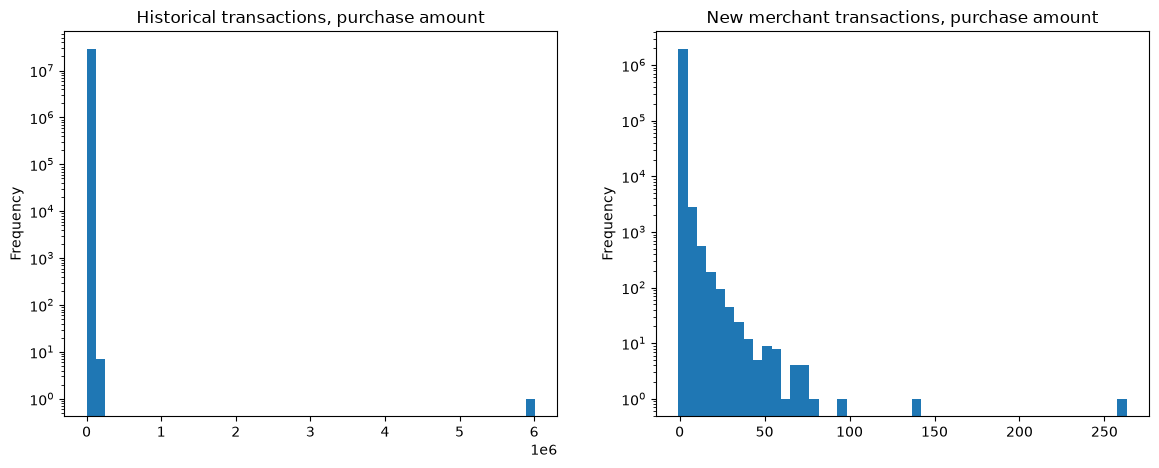

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
history_df['purchase_amount'].plot(kind='hist', logy=True, bins=48, ax=ax[0], title='Historical transactions, purchase amount')
new_merch_df['purchase_amount'].plot(kind='hist', logy=True, bins=48, ax=ax[1], title='New merchant transactions, purchase amount')
plt.show()

In [11]:
history_df['purchase_amount'].sort_values(ascending=False)

29050360    6.010604e+06
19745877    1.652987e+05
20537106    1.472606e+05
28417440    1.382450e+05
24263772    1.357661e+05
                ...     
10870853   -7.469078e-01
28998861   -7.469078e-01
3866275    -7.469078e-01
25423508   -7.469078e-01
630405     -7.469078e-01
Name: purchase_amount, Length: 29112361, dtype: float64

Видим по графикам, что в данных есть сильный разброс. Использование StandardScaler не даст нужного результата, поскольку он чувствителен к выбросам. Поэтому, попробуем использовать RobustScaler и посмотрим на реузльтат.

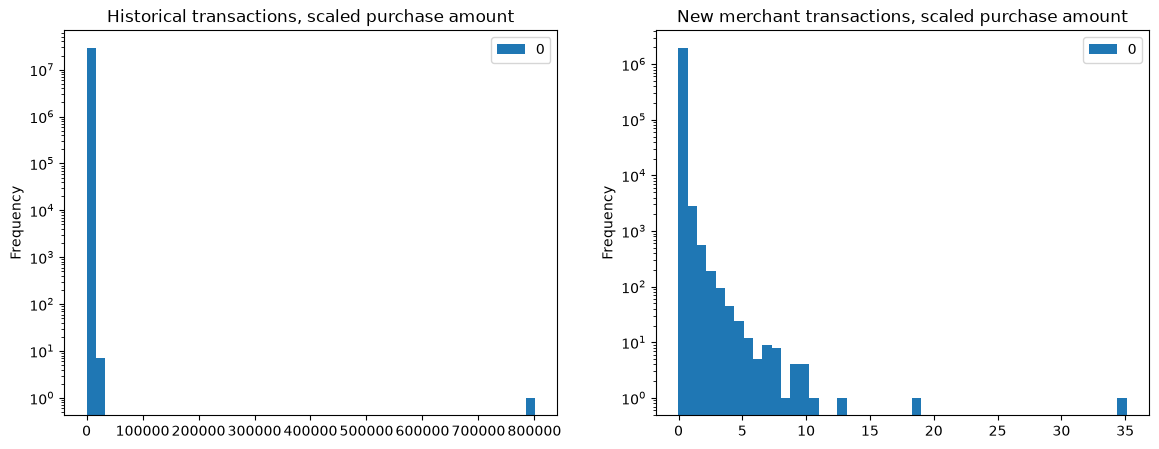

In [12]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler(quantile_range=(5.0, 99.9)) #используем 5 и 99.9 квартили для ограничения выбросов
h_x = scaler.fit_transform(pd.DataFrame(history_df['purchase_amount']))
n_x = scaler.fit_transform(pd.DataFrame(new_merch_df['purchase_amount']))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
pd.DataFrame(h_x).plot(kind='hist', logy=True, bins=48, ax=ax[0], title='Historical transactions, scaled purchase amount')
pd.DataFrame(n_x).plot(kind='hist', logy=True, bins=48, ax=ax[1], title='New merchant transactions, scaled purchase amount')
plt.show()

Видим, что глобально картина не меняется, поэтому использование RobustScaler не оправдано. В качестве **гипотезы**, попробуем использовать выбросы как отдельный признак. Если purchase amount выше определенного значения, то покупка будет считаться выбросом (очень дорогой покупкой), и модель будет обрабатывать новый признак. Также стоит попоробовать **другой подход** с разделением суммы покупки на группы (очень малая, малая, средняя, большая).

In [13]:
# Заполним пропуски 

test_df['first_active_month'] = test_df['first_active_month'].fillna(test_df['first_active_month'].mode()[0])

history_df['category_2'] = history_df['category_2'].fillna(history_df['category_2'].mode()[0])
history_df['category_3'] = history_df['category_3'].fillna(history_df['category_3'].mode()[0])
history_df['merchant_id'] = history_df['merchant_id'].fillna(history_df['merchant_id'].mode()[0])

new_merch_df['category_2'] = new_merch_df['category_2'].fillna(new_merch_df['category_2'].mode()[0])
new_merch_df['category_3'] = new_merch_df['category_3'].fillna(new_merch_df['category_3'].mode()[0])
new_merch_df['merchant_id'] = new_merch_df['merchant_id'].fillna(new_merch_df['merchant_id'].mode()[0])

merchants_df['avg_sales_lag3'] = merchants_df['avg_sales_lag3'].fillna(merchants_df['avg_sales_lag3'].mode()[0])
merchants_df['avg_sales_lag6'] = merchants_df['avg_sales_lag6'].fillna(merchants_df['avg_sales_lag6'].mode()[0])
merchants_df['avg_sales_lag12'] = merchants_df['avg_sales_lag12'].fillna(merchants_df['avg_sales_lag12'].mode()[0])
merchants_df['category_2'] = merchants_df['category_2'].fillna(merchants_df['category_2'].mode()[0])

In [14]:
print(f'Пропуски по train (строк: {len(train_df)}): \n {train_df.isna().sum()} \n')
print(f'Пропуски по test (строк: {len(test_df)}): \n {test_df.isna().sum()} \n')
print(f'Пропуски по historical_transactions (строк: {len(history_df)}): \n {history_df.isna().sum()} \n')
print(f'Пропуски по new_merchants_transactions (строк: {len(new_merch_df)}): \n {new_merch_df.isna().sum()} \n')
print(f'Пропуски по merchants (строк: {len(merchants_df)}): \n {merchants_df.isna().sum()} \n')

Пропуски по train (строк: 201917): 
 first_active_month    0
card_id               0
feature_1             0
feature_2             0
feature_3             0
target                0
dtype: int64 

Пропуски по test (строк: 123623): 
 first_active_month    0
card_id               0
feature_1             0
feature_2             0
feature_3             0
dtype: int64 

Пропуски по historical_transactions (строк: 29112361): 
 authorized_flag         0
card_id                 0
city_id                 0
category_1              0
installments            0
category_3              0
merchant_category_id    0
merchant_id             0
month_lag               0
purchase_amount         0
purchase_date           0
category_2              0
state_id                0
subsector_id            0
is_approved             0
dtype: int64 

Пропуски по new_merchants_transactions (строк: 1963031): 
 authorized_flag         0
card_id                 0
city_id                 0
category_1              0
installm

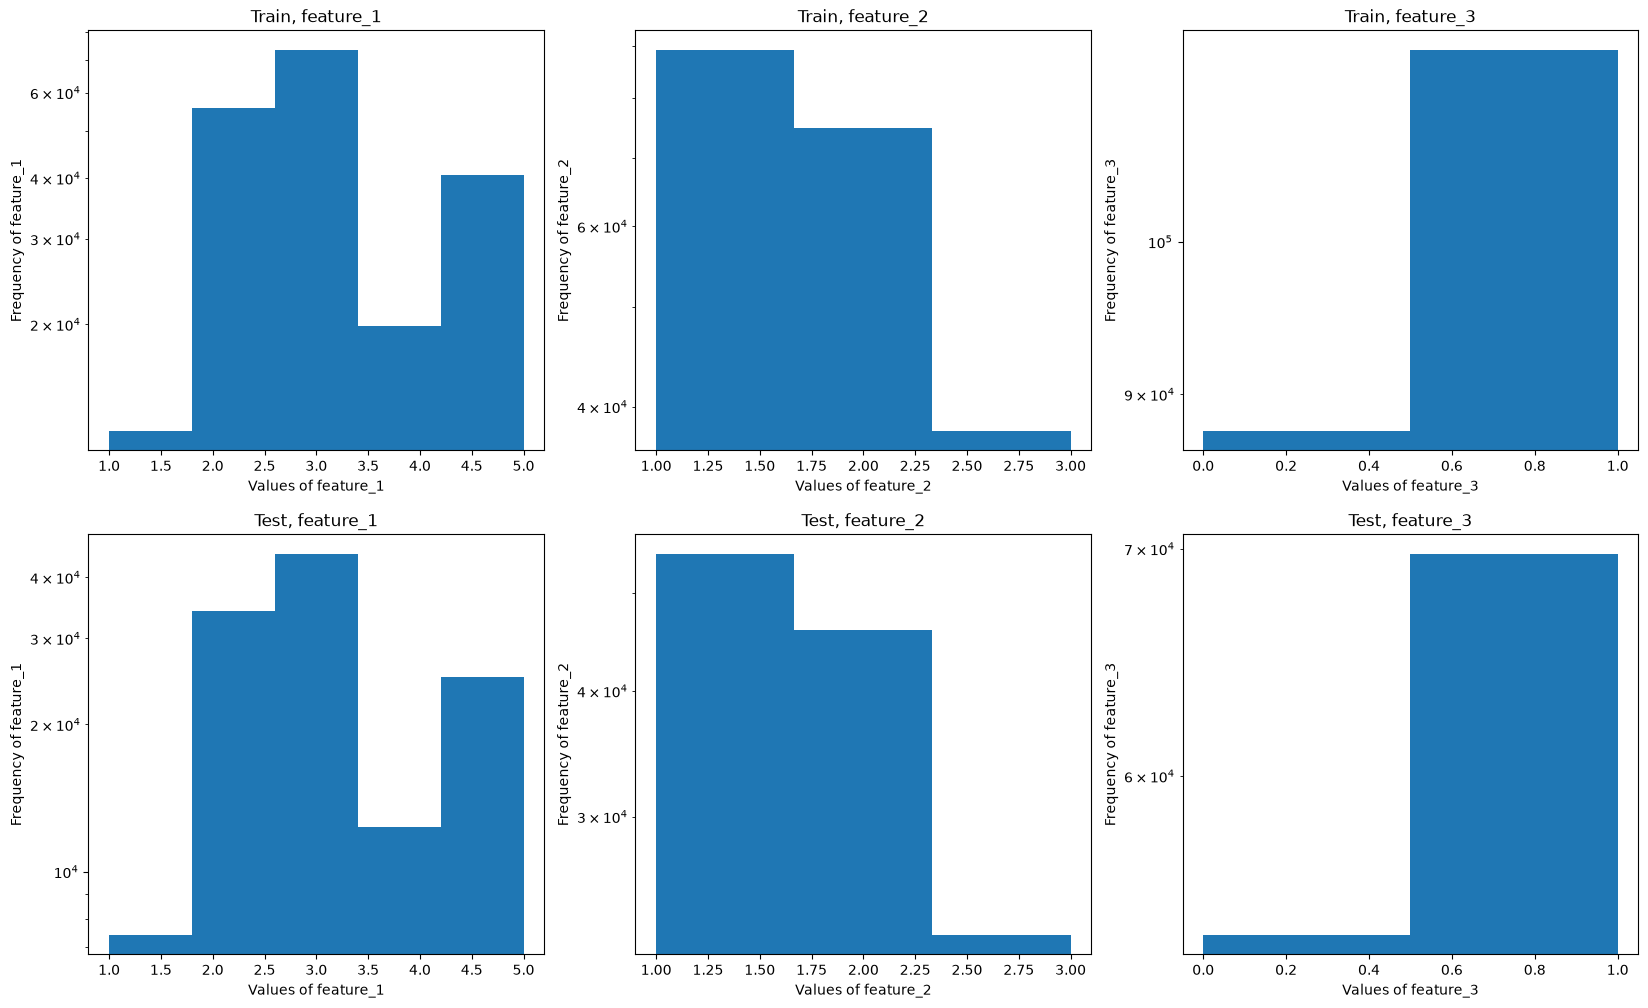

In [15]:
# Построим распределения базовых признаков
base_features = ['feature_1', 'feature_2', 'feature_3']

fig, ax = plt.subplots(2, 3, figsize=(20, 12))
for i, feature in enumerate(base_features):
    ax[0, i].hist(train_df[feature], bins=len(train_df[feature].unique()))
    ax[0, i].set_yscale('log')
    ax[0, i].set_title(f'Train, {feature}')
    ax[0, i].set_ylabel(f'Frequency of {feature}')
    ax[0, i].set_xlabel(f'Values of {feature}') 
    
    ax[1, i].hist(test_df[feature], bins=len(test_df[feature].unique()))
    ax[1, i].set_yscale('log')
    ax[1, i].set_title(f'Test, {feature}')
    ax[1, i].set_ylabel(f'Frequency of {feature}')
    ax[1, i].set_xlabel(f'Values of {feature}') 

Построим **распределения ключевых признаков** historical_transactions/new_merchants_transactions:
1) category_1/3 - str
2) category_2 - float
3) installments, month_lag, is_approved - int
4) purchase_amount - float (уже построено)

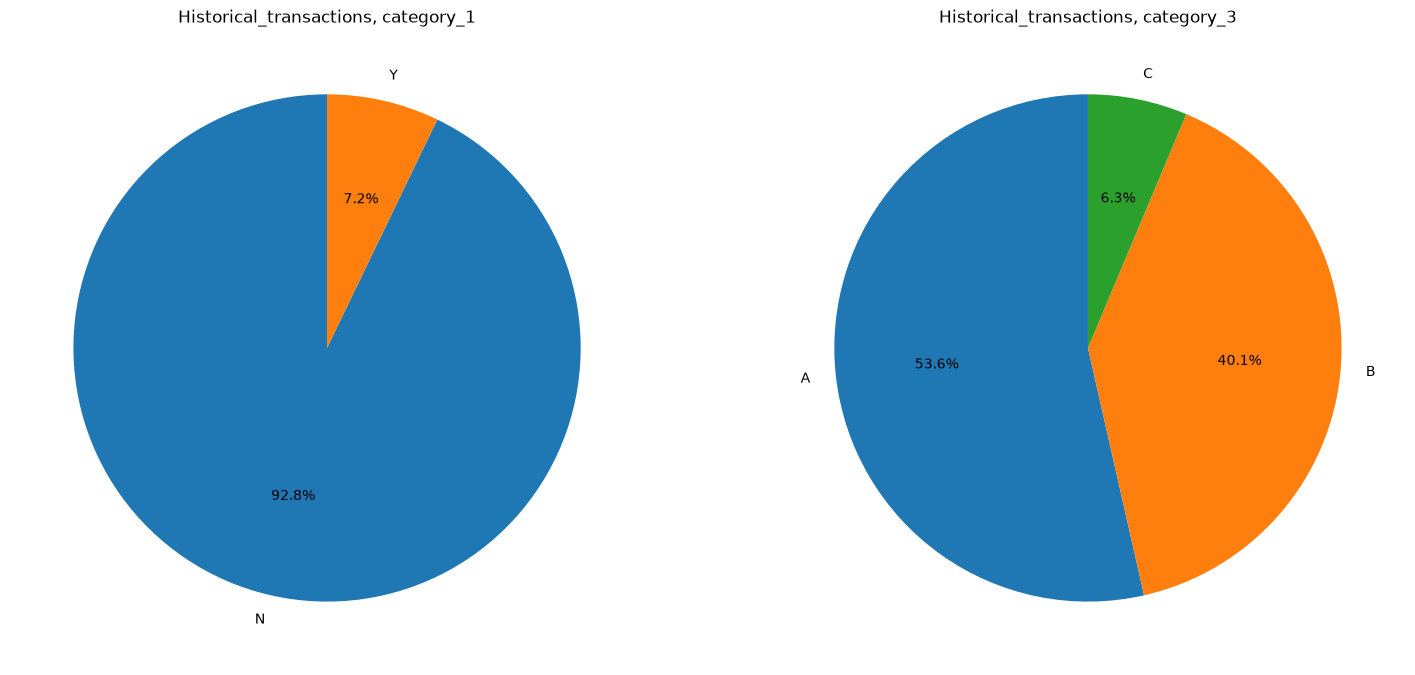

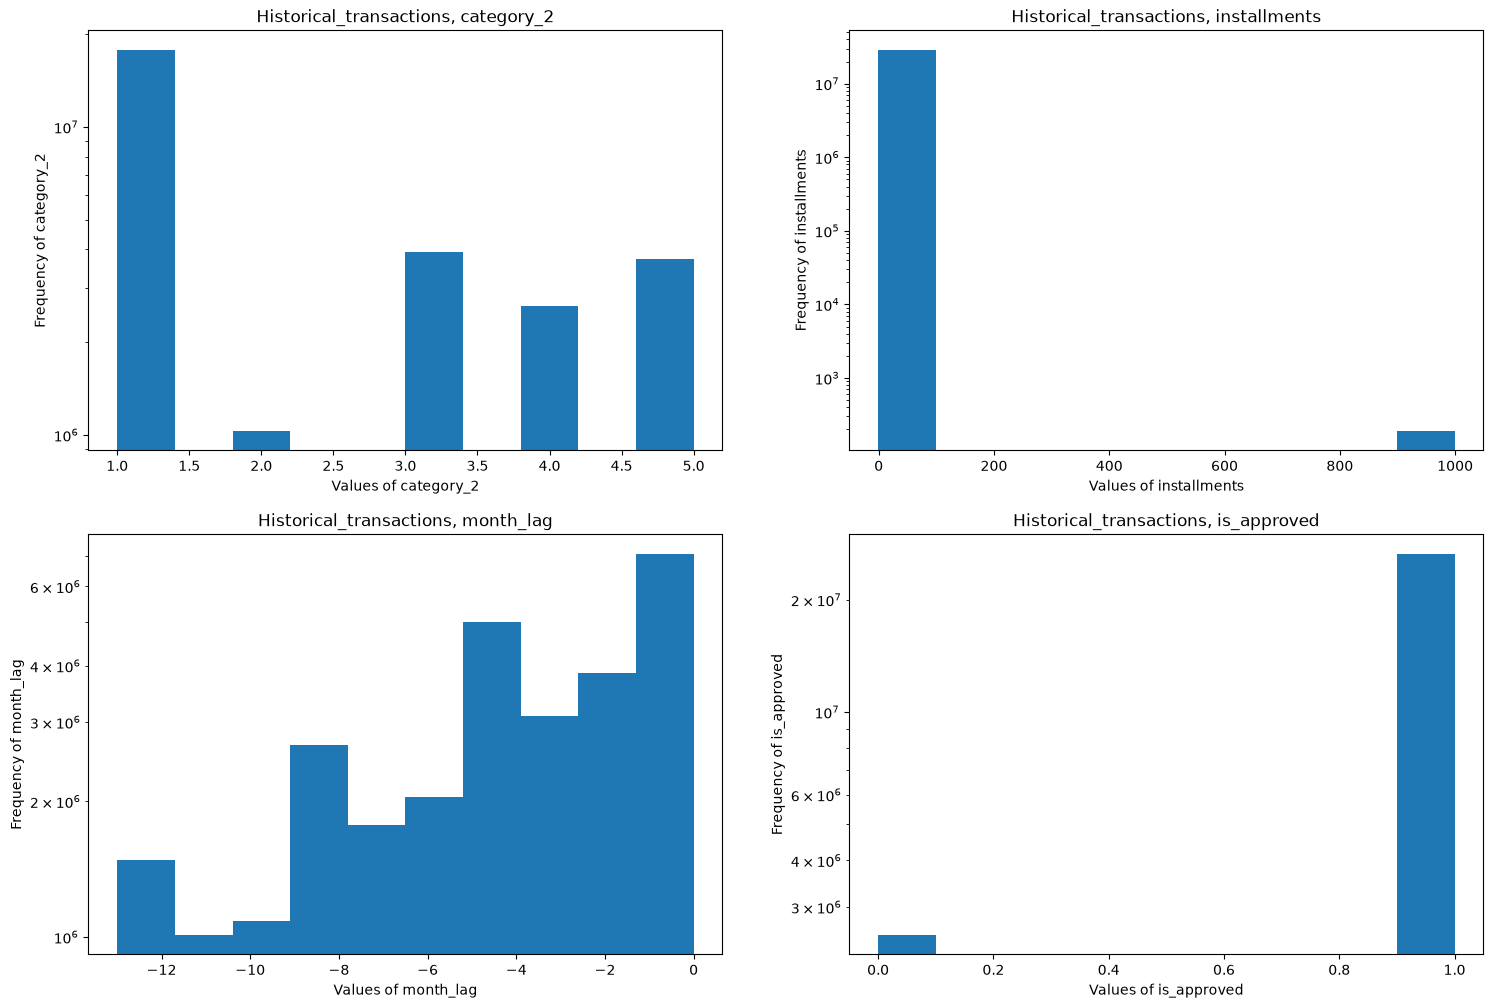

In [16]:
# Сначала построим для historical_transactions
str_features = ['category_1', 'category_3']
int_float_features = ['category_2', 'installments', 'month_lag', 'is_approved']

fig, ax = plt.subplots(1, 2, figsize=(18, 10))

for i, feature in enumerate(str_features):
    history_df[feature].value_counts().plot(kind='pie', ax=ax[i], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(f'Historical_transactions, {feature}')


fig, axs = plt.subplots(2, 2, figsize=(18, 12))

for ax, feature in zip(axs.flat, int_float_features):
    history_df[feature].plot(kind='hist', ax=ax)
    ax.set_title(f'Historical_transactions, {feature}')
    ax.set_yscale('log')
    ax.set_ylabel(f'Frequency of {feature}')
    ax.set_xlabel(f'Values of {feature}') 

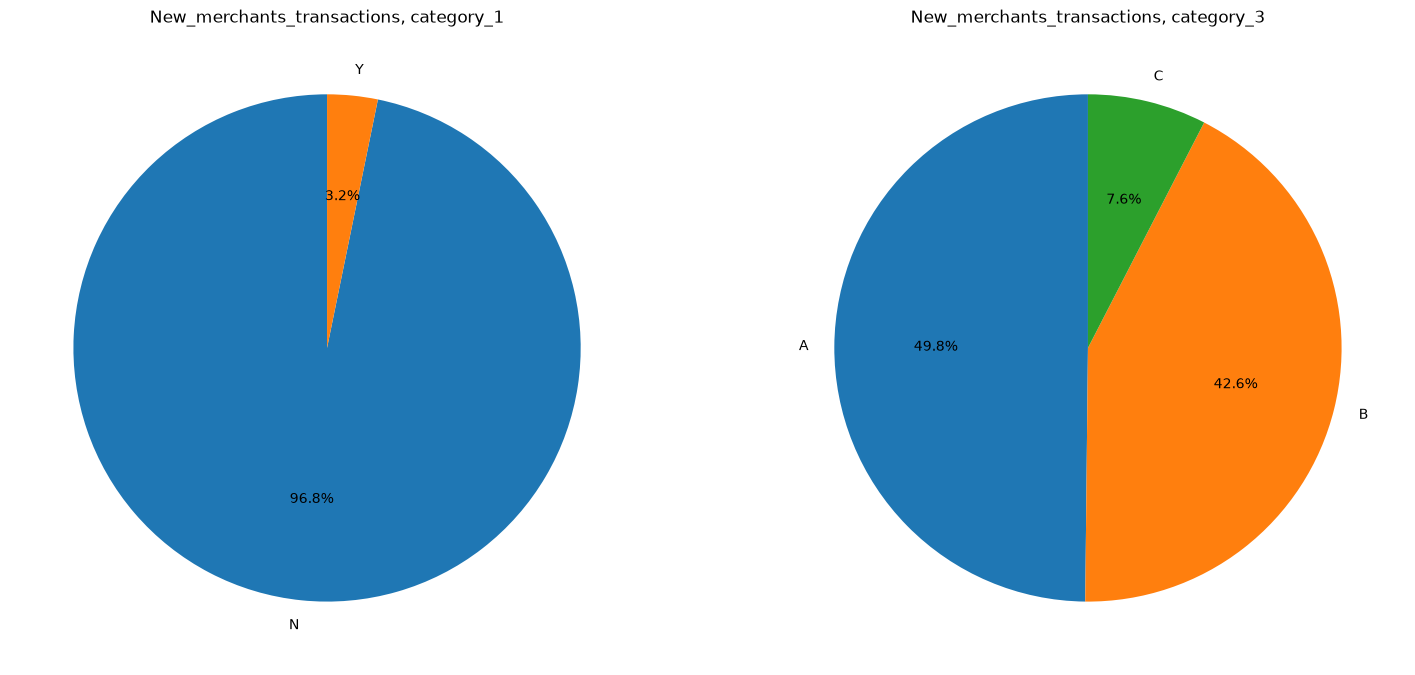

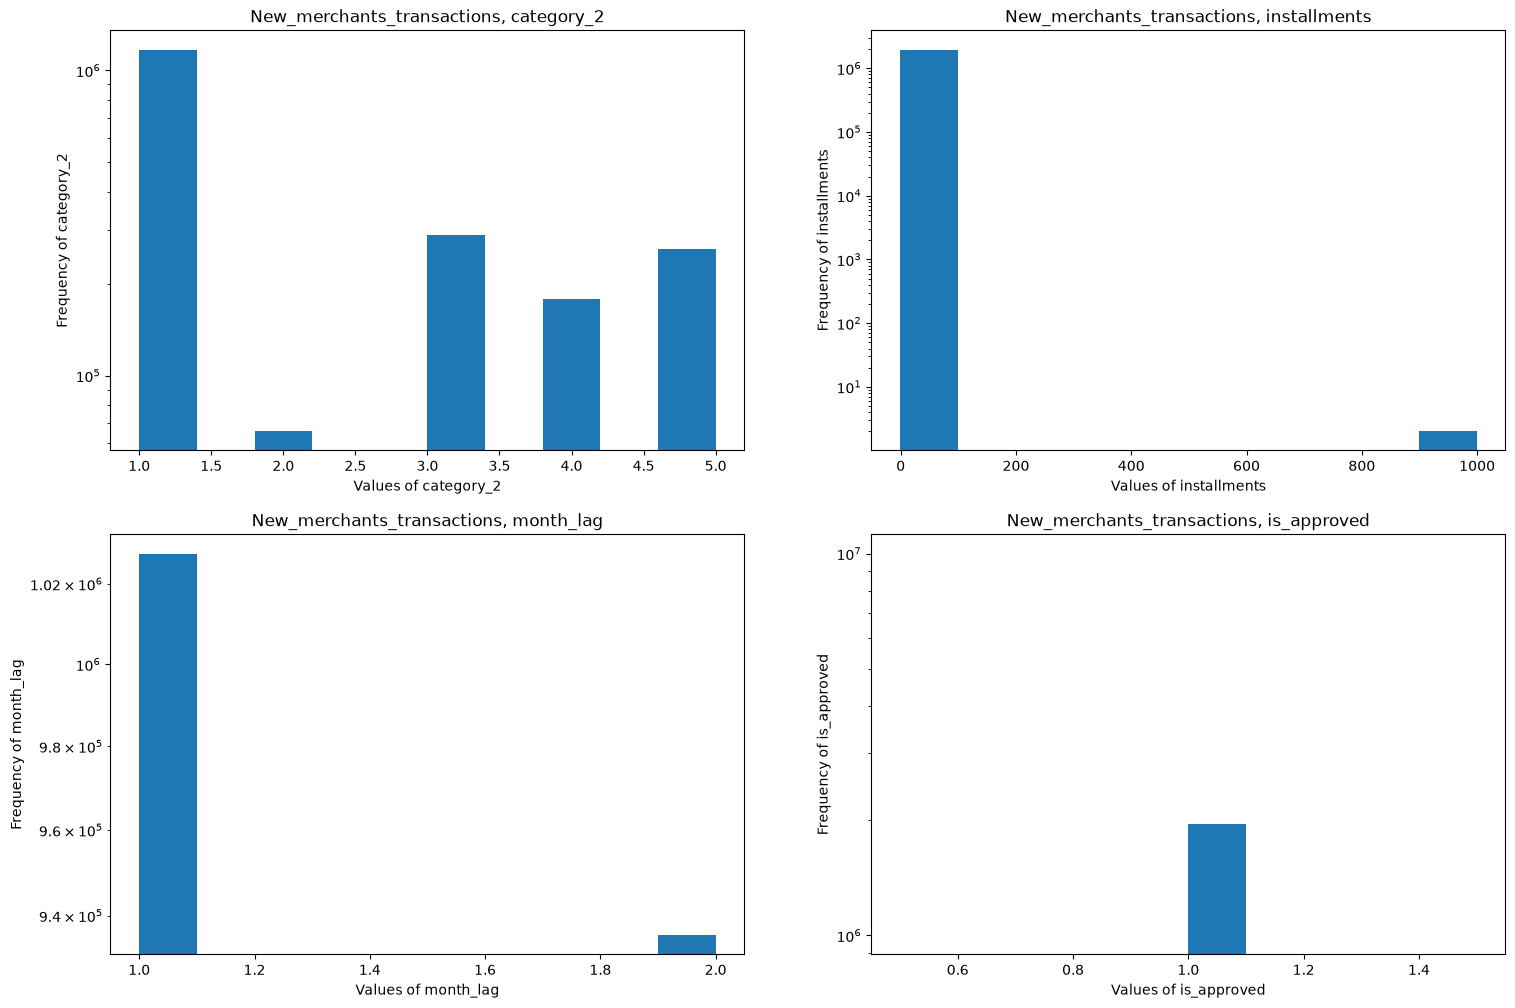

In [17]:
# Сначала построим для new_merchants_transactions
str_features = ['category_1', 'category_3']
int_float_features = ['category_2', 'installments', 'month_lag', 'is_approved']

fig, ax = plt.subplots(1, 2, figsize=(18, 10))

for i, feature in enumerate(str_features):
    new_merch_df[feature].value_counts().plot(kind='pie', ax=ax[i], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(f'New_merchants_transactions, {feature}')


fig, axs = plt.subplots(2, 2, figsize=(18, 12))

for ax, feature in zip(axs.flat, int_float_features):
    new_merch_df[feature].plot(kind='hist', ax=ax)
    ax.set_title(f'New_merchants_transactions, {feature}')
    ax.set_yscale('log')
    ax.set_ylabel(f'Frequency of {feature}')
    ax.set_xlabel(f'Values of {feature}') 

## 3. Feature Engineering

In [18]:
# Добавим всевозможные признаки и построим матрицу корреляций

def full_aggregate_transactions(df, prefix):
    df['purchase_month'] = df['purchase_date'].dt.month

    # Создаем категориальные признаки по сумме покупки. 
    # От идеи бинарного признака отказываемся по причине сложности определения конкретного диапазона выбросов.
    bins = [-np.inf, 0, 10, 50, 150, np.inf]
    labels = ['very_small', 'small', 'medium', 'large', 'very_large']
    
    df['amount_bin'] = pd.cut(df['purchase_amount'], bins=bins, labels=labels)

    # При агрегации считаем долю каждой категории для клиента
    bins_df = pd.get_dummies(df['amount_bin'], prefix=f'{prefix}_amount_bin')
    bins_df['card_id'] = df['card_id']
    
    bin_agg = bins_df.groupby('card_id').mean().reset_index()
    
    agg = df.groupby('card_id').agg(
        **{
            f'{prefix}_trans_count': ('card_id', 'count'),
            f'{prefix}_purchase_amount_mean': ('purchase_amount', 'mean'),
            f'{prefix}_purchase_amount_sum': ('purchase_amount', 'sum'),
            f'{prefix}_purchase_amount_std': ('purchase_amount', 'std'),
            f'{prefix}_purchase_amount_max': ('purchase_amount', 'max'),
            f'{prefix}_approved_ratio': ('is_approved', 'mean'),
            f'{prefix}_avg_installments': ('installments', 'mean'),
            f'{prefix}_month_lag': ('month_lag', 'mean'),
            f'{prefix}_most_common_month': ('purchase_month', lambda x: x.mode()[0] if not x.mode().empty else np.nan), 
            f'{prefix}_category_1': ('category_1', lambda x: x.mode()[0]),
            f'{prefix}_category_2': ('category_2', lambda x: x.mode()[0]),
            f'{prefix}_category_3': ('category_3', lambda x: x.mode()[0])
        }
    ).reset_index()

    result = agg.merge(bin_agg, on='card_id', how='left')
    return result

hist_agg = full_aggregate_transactions(history_df, 'history')
new_merch_agg = full_aggregate_transactions(new_merch_df, 'new_merch')
hist_agg.head(10)

,card_id,history_trans_count,history_purchase_amount_mean,history_purchase_amount_sum,history_purchase_amount_std,history_purchase_amount_max,history_approved_ratio,history_avg_installments,history_month_lag,history_most_common_month,history_category_1,history_category_2,history_category_3,history_amount_bin_very_small,history_amount_bin_small,history_amount_bin_medium,history_amount_bin_large,history_amount_bin_very_large
0,C_ID_00007093c1,149,-0.515739,-76.845041,0.298141,1.507069,0.765101,1.288591,-5.852349,6,N,3.0,B,0.932886,0.067114,0.0,0.0,0.0
1,C_ID_0001238066,123,-0.589002,-72.447201,0.190235,0.768095,0.975610,1.609756,-1.813008,12,N,1.0,B,0.983740,0.016260,0.0,0.0,0.0
2,C_ID_0001506ef0,66,-0.524271,-34.601879,0.472284,1.493545,0.939394,0.015152,-4.833333,12,N,3.0,A,0.878788,0.121212,0.0,0.0,0.0
3,C_ID_0001793786,216,-0.170306,-36.786013,0.836046,4.554145,0.875000,0.023148,-3.328704,9,N,1.0,A,0.782407,0.217593,0.0,0.0,0.0
4,C_ID_000183fdda,144,-0.478041,-68.837938,0.524948,2.764788,0.951389,1.833333,-2.451389,1,N,3.0,B,0.895833,0.104167,0.0,0.0,0.0
5,C_ID_00024e244b,70,-0.593611,-41.552753,0.416742,2.258395,0.757143,0.071429,-6.342857,8,N,3.0,A,0.957143,0.042857,0.0,0.0,0.0
6,C_ID_0002709b5a,73,-0.652870,-47.659542,0.078777,-0.336684,0.917808,1.767123,-4.328767,12,N,2.0,B,1.000000,0.000000,0.0,0.0,0.0
7,C_ID_00027503e2,42,-0.741025,-31.123047,0.003334,-0.734135,0.571429,0.000000,-4.142857,7,N,3.0,A,1.000000,0.000000,0.0,0.0,0.0
8,C_ID_000298032a,30,-0.533081,-15.992416,0.589542,2.577843,0.933333,0.000000,-4.100000,1,N,1.0,A,0.966667,0.033333,0.0,0.0,0.0
9,C_ID_0002ba3c2e,70,-0.633471,-44.342996,0.129401,-0.097011,0.785714,0.000000,-3.314286,9,N,2.0,A,1.000000,0.000000,0.0,0.0,0.0


In [19]:
# def basic_aggregate_transactions(df, prefix):
#     agg = df.groupby('card_id').agg(
#         **{
#             f'{prefix}_trans_count': ('card_id', 'count'),
#             f'{prefix}_purchase_amount_mean': ('purchase_amount', 'mean'),
#             f'{prefix}_approved_ratio': ('is_approved', 'mean'),
#             f'{prefix}_category_1': ('category_1', lambda x: x.mode()[0]), 
#             f'{prefix}_category_2': ('category_2', lambda x: x.mode()[0]),
#             f'{prefix}_category_3': ('category_3', lambda x: x.mode()[0])
#         }
#     ).reset_index()
#     return agg

In [20]:
train_all_features = train_df.merge(hist_agg, on='card_id', how='left')
train_all_features = train_all_features.merge(new_merch_agg, on='card_id', how='left')

test_all_features = test_df.merge(hist_agg, on='card_id', how='left')
test_all_features = test_all_features.merge(new_merch_agg, on='card_id', how='left')

print(train_all_features.isna().sum())
print(test_all_features.isna().sum())

first_active_month                     0
card_id                                0
feature_1                              0
feature_2                              0
feature_3                              0
target                                 0
history_trans_count                    0
history_purchase_amount_mean           0
history_purchase_amount_sum            0
history_purchase_amount_std            0
history_purchase_amount_max            0
history_approved_ratio                 0
history_avg_installments               0
history_month_lag                      0
history_most_common_month              0
history_category_1                     0
history_category_2                     0
history_category_3                     0
history_amount_bin_very_small          0
history_amount_bin_small               0
history_amount_bin_medium              0
history_amount_bin_large               0
history_amount_bin_very_large          0
new_merch_trans_count              21931
new_merch_purcha

In [21]:
# Заполним получившиеся пропуски модами
# Удаляем лишние признаки
# Приводим строковые признаки к категориальным для дальнейшей работы с деревьями и бустингами
train_all_features = train_all_features.fillna(train_all_features.mode().iloc[0])
test_all_features = test_all_features.fillna(test_all_features.mode().iloc[0])

train = train_all_features.drop(['card_id', 'first_active_month', 'target'], axis=1)
test = test_all_features.drop(['card_id', 'first_active_month'], axis=1)
train_target = train_all_features['target']

train[train.select_dtypes(include=['str']).columns.tolist()] = train[train.select_dtypes(include=['str']).columns.tolist()].astype('category')
test[test.select_dtypes(include=['str']).columns.tolist()] = test[test.select_dtypes(include=['str']).columns.tolist()].astype('category')

train.isna().sum()

feature_1                          0
feature_2                          0
feature_3                          0
history_trans_count                0
history_purchase_amount_mean       0
history_purchase_amount_sum        0
history_purchase_amount_std        0
history_purchase_amount_max        0
history_approved_ratio             0
history_avg_installments           0
history_month_lag                  0
history_most_common_month          0
history_category_1                 0
history_category_2                 0
history_category_3                 0
history_amount_bin_very_small      0
history_amount_bin_small           0
history_amount_bin_medium          0
history_amount_bin_large           0
history_amount_bin_very_large      0
new_merch_trans_count              0
new_merch_purchase_amount_mean     0
new_merch_purchase_amount_sum      0
new_merch_purchase_amount_std      0
new_merch_purchase_amount_max      0
new_merch_approved_ratio           0
new_merch_avg_installments         0
n

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_selector

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), make_column_selector(dtype_include='number')),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), 
         make_column_selector(dtype_include=['category']))
    ],
    remainder='drop' 
)

X_train_num = preprocessor.fit_transform(train)
X_test_num = preprocessor.transform(test)

feature_names = preprocessor.get_feature_names_out()

X_train_num_df = pd.DataFrame(X_train_num, columns=feature_names)
X_test_num_df = pd.DataFrame(X_test_num, columns=feature_names)

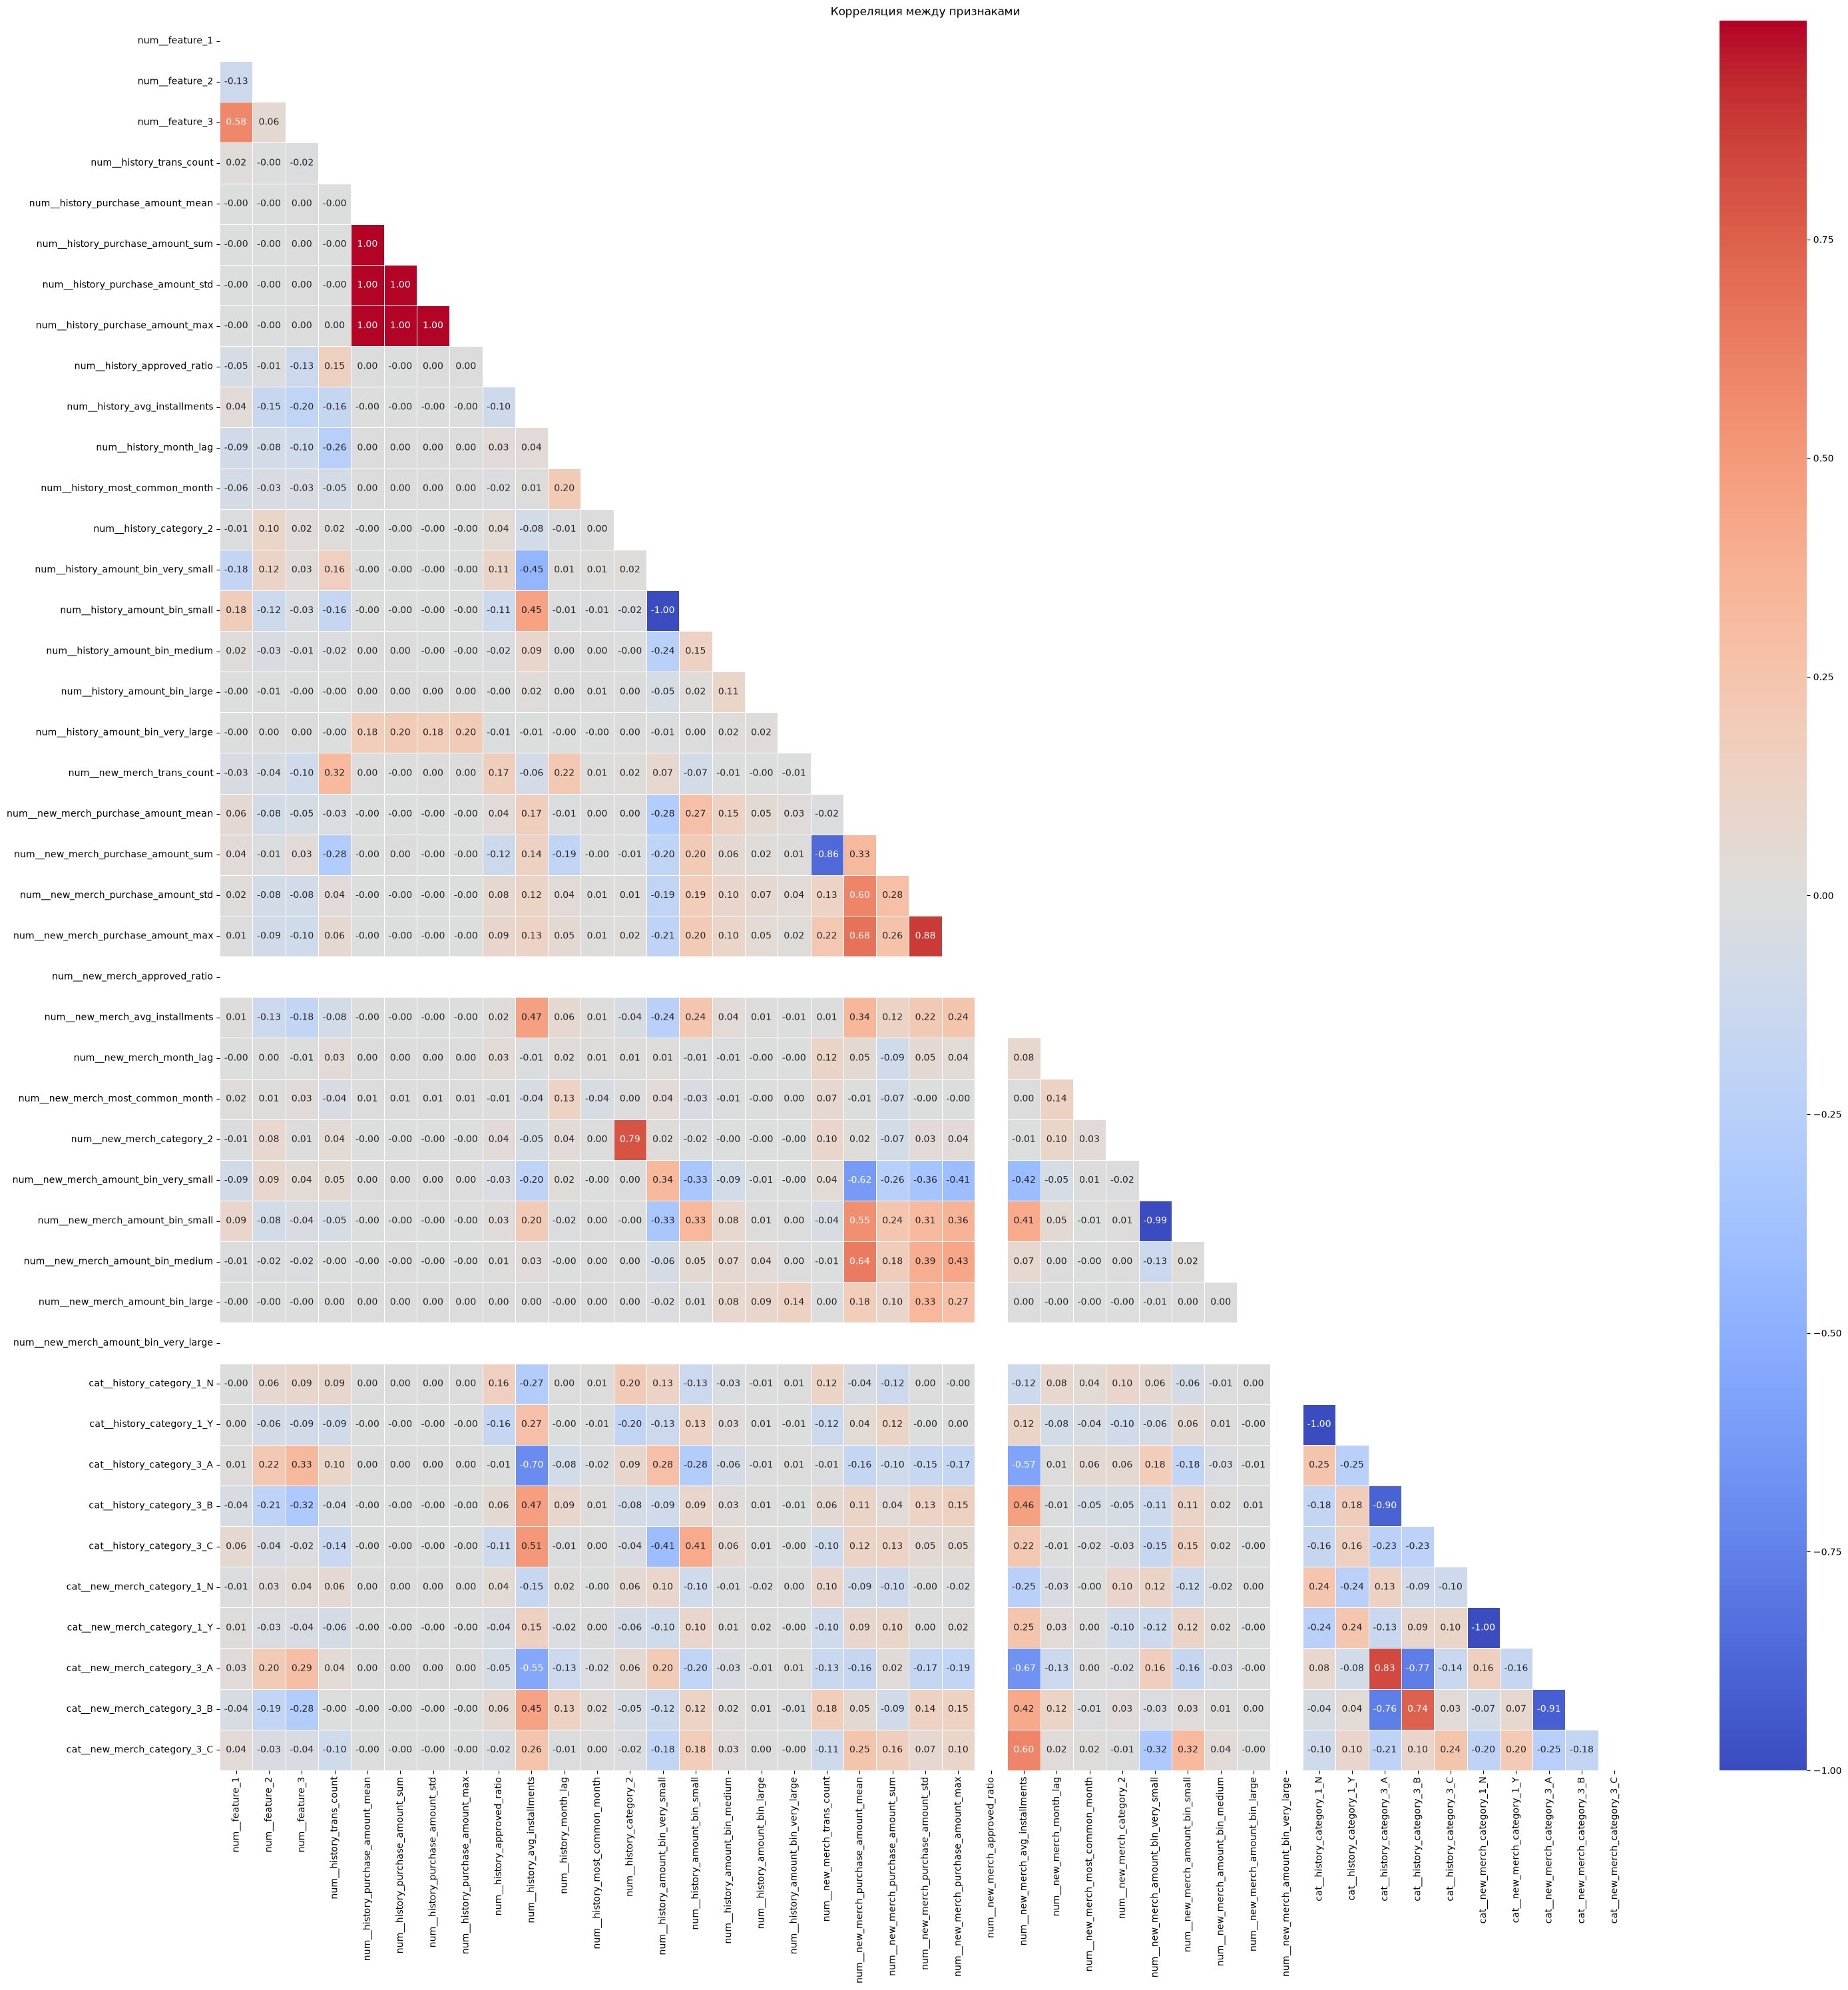

In [23]:
# Построение корреляционной матрицы
corr = X_train_num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(30, 30))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

В общем и целом, признаки не являются сильнокоррелированными. За исключением признаков, которые математически по природе своей коррелированы с похожими признаками.

## 4. Baseline

In [35]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

linear_models = [Ridge(), Lasso()]
results = []

pipeline = lambda model: Pipeline([
    ('preprocessor', preprocessor), 
    ('model', model)
])

param_grid_linear = {
    'model__alpha': [0.1, 0.01, 0.001, 0.0001, 0.00001, 0.5, 1.0, 5.0, 10.0]
}

for model in linear_models:
    grid_linear = GridSearchCV(
        pipeline(model),
        param_grid_linear,
        cv=10, 
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    
    grid_linear.fit(train, train_target)
    
    results.append({
        'Model': f'{str(model).translate({ord(c): None for c in "()"})}(alpha={grid_linear.best_params_['model__alpha']})',
        'RMSE': grid_linear.best_score_,
    })

pd.DataFrame(results)

,Model,RMSE
0,Ridge(alpha=10.0),-3.821019
1,Lasso(alpha=0.01),-3.809361


In [44]:
best_model = grid_linear.best_estimator_
lasso = best_model.named_steps['model']    
selected_mask = lasso.coef_ != 0
selected_features = X_train_num_df.columns[selected_mask]

Index(['num__feature_1', 'num__feature_2', 'num__feature_3',
       'num__history_approved_ratio', 'num__history_month_lag',
       'num__history_most_common_month', 'num__history_category_2',
       'num__history_amount_bin_very_small',
       'num__history_amount_bin_very_large', 'num__new_merch_trans_count',
       'num__new_merch_purchase_amount_mean',
       'num__new_merch_purchase_amount_sum',
       'num__new_merch_purchase_amount_std', 'num__new_merch_avg_installments',
       'num__new_merch_month_lag', 'num__new_merch_most_common_month',
       'num__new_merch_category_2', 'num__new_merch_amount_bin_small',
       'num__new_merch_amount_bin_medium', 'num__new_merch_amount_bin_large',
       'cat__history_category_1_N', 'cat__history_category_1_Y',
       'cat__history_category_3_B'],
      dtype='str')

In [26]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

params = {
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': 42,
}

xgb_param_grid = {
    'model__max_depth': [5, 6, 8, 10],
    'model__n_estimators': [500, 700, 900, 1000, 1500],
    'model__learning_rate': [0.01, 0.001, 0.0001, 0.05]
}

xgb_grid = RandomizedSearchCV(
    pipeline(xgb.XGBRegressor(**params)),
    xgb_param_grid,
    cv=5,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    n_jobs=1
)

xgb_grid.fit(train, train_target)

results.append({
        'Model': 'XGBoost',
        'RMSE': xgb_grid.best_score_,
    })


pd.DataFrame(results).set_index('Model')

C:\ProgramData\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:01:59] WARNING: D:\bld\xgboost-split_1733179550881\work\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


,RMSE
Model,
Ridge(alpha=10.0),-3.821019
Lasso(alpha=0.01),-3.809361
XGBoost,-3.729416


In [27]:
best_xgb = xgb_grid.best_estimator_

y_pred_xgb = best_xgb.predict(test)
sample_df = pd.read_csv(r'data/sample_submission.csv')
sample_df['target'] = y_pred_xgb

sample_df.to_csv('xgb.csv', index=False)
# Первый LB_score ~ 3.68526

In [28]:
print(xgb_grid.best_params_)

{'model__n_estimators': 1500, 'model__max_depth': 5, 'model__learning_rate': 0.01}


In [31]:
import lightgbm as lgb
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

params = {
    # 'device': 'gpu',           
    # 'gpu_use_dp': False,        
    'random_state': 42,
    'verbose': -1
}

lgb_param_grid = {
    'model__max_depth': [4, 5, 6],
    'model__n_estimators': [1000, 1500, 2000],
    'model__learning_rate': [0.01, 0.001, 0.05]
}

lgb_grid = RandomizedSearchCV(
    pipeline(lgb.LGBMRegressor(**params)),
    lgb_param_grid,
    cv=5,
    n_iter=15,
    scoring='neg_root_mean_squared_error',
    n_jobs=1
)

lgb_grid.fit(train, train_target)

results.append({
        'Model': 'Ligth GBM',
        'RMSE': lgb_grid.best_score_,
    })


pd.DataFrame(results).set_index('Model')

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packag

,RMSE
Model,
Ridge(alpha=10.0),-3.821019
Lasso(alpha=0.01),-3.809361
XGBoost,-3.729416
Ligth GBM,-3.727865


In [32]:
best_lgb = lgb_grid.best_estimator_

y_pred_lgb = best_lgb.predict(test)
sample_df = pd.read_csv(r'data/sample_submission.csv')
sample_df['target'] = y_pred_lgb

sample_df.to_csv('lgb.csv', index=False)
# Второй LB_score ~ 3.68424

print(lgb_grid.best_params_)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'model__n_estimators': 1000, 'model__max_depth': 6, 'model__learning_rate': 0.01}


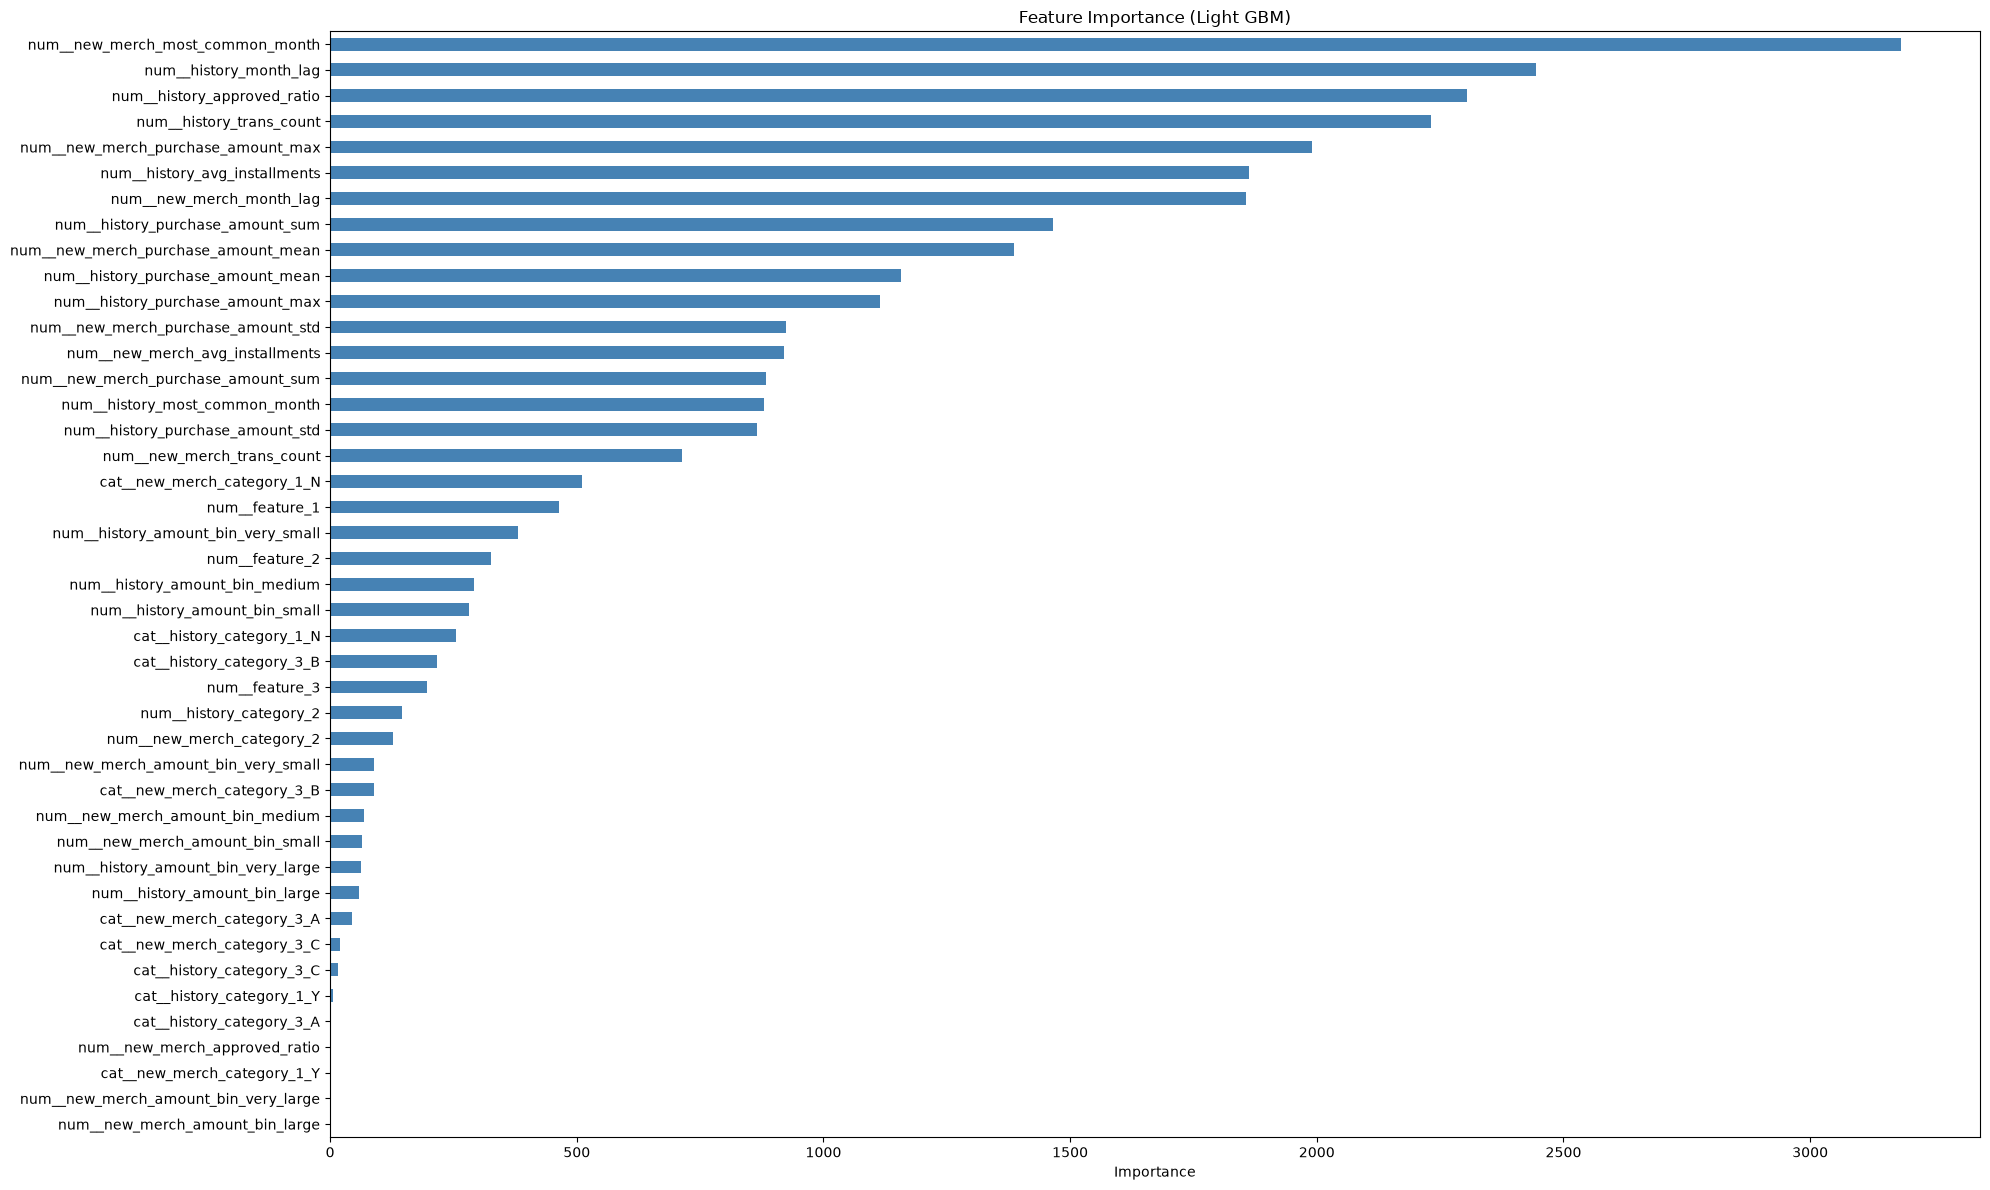

In [107]:
preprocessor = best_lgb.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()
lgb_model = best_lgb.named_steps['model']

fig, ax = plt.subplots(figsize=(20, 12))
importances = pd.Series(lgb_model.feature_importances_, index=feature_names).sort_values(ascending=True)
importances.plot.barh(ax=ax, color='steelblue')
ax.set_title(f'Feature Importance (Light GBM)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [130]:
select_lgbm = importances.sort_values(ascending=False).iloc[:20].index.tolist()

## 5. Blending/Stacking
Сначала попробуем сделать базовый блендинг по усреднению XGBoost и LightGBM на всех признаках. Затем, обучим тот же блендинг на отобранных через LGBM признаках. После этого, попробуем стекинг на отобранных признаках.

In [146]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1500,
    learning_rate=0.01,
    max_depth=5,
    random_state=42,
    tree_method='hist',
    device='cuda',  
    verbose=-1
)

pipeline(xgb_model).fit(train, train_target)
xgb_pred = pipeline(xgb_model).predict(test)

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    random_state=42,
    verbose=-1
)
pipeline(lgb_model).fit(train, train_target)
lgb_pred = pipeline(lgb_model).predict(test)

# 3. Блендинг: усреднение
blend_pred = (xgb_pred + lgb_pred) / 2

sample_df = pd.read_csv(r'data/sample_submission.csv')
sample_df['target'] = blend_pred

sample_df.to_csv('blending.csv', index=False)
# Третий LB_score ~ 3.68298

C:\ProgramData\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [01:18:51] WARNING: D:\bld\xgboost-split_1733179550881\work\src\learner.cc:740: 
Parameters: { "verbose" } are not used.

  warnings.warn(smsg, UserWarning)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [131]:
xgb_model.fit(X_train_num_df[select_lgbm], train_target)
lgb_model.fit(X_train_num_df[select_lgbm], train_target)

xgb_select_pred = xgb_model.predict(X_test_num_df[select_lgbm])
lgb_select_pred = lgb_model.predict(X_test_num_df[select_lgbm])

# 3. Блендинг: усреднение на отобранных признаках
blend_select_pred = (xgb_select_pred + lgb_select_pred) / 2

sample_df = pd.read_csv(r'data/sample_submission.csv')
sample_df['target'] = blend_select_pred

sample_df.to_csv('blending_select.csv', index=False)
# Четвертый LB_score ~ 3.68512

C:\ProgramData\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:44:14] WARNING: D:\bld\xgboost-split_1733179550881\work\src\learner.cc:740: 
Parameters: { "verbose" } are not used.

  warnings.warn(smsg, UserWarning)


После отбора признаков метрика просела. Делаем вывод, что бустинги самостоятельно справляются с отбором всех признаков, потому отбор здесь излишен.

In [134]:
# Попробуем добавить Lasso 

lasso = Lasso(alpha=0.01)

xgb_model.fit(X_train_num_df, train_target)
lgb_model.fit(X_train_num_df, train_target)
lasso.fit(X_train_num_df, train_target)


xgb_pred = xgb_model.predict(X_test_num_df)
lgb_pred = lgb_model.predict(X_test_num_df)
lasso_pred = lasso.predict(X_test_num_df)

# 3. Блендинг: усреднение с Лассо
blend_lasso_pred = (0.4 * xgb_select_pred + 0.4 * lgb_select_pred + 0.2 * lasso_pred)

sample_df = pd.read_csv(r'data/sample_submission.csv')
sample_df['target'] = blend_lasso_pred

sample_df.to_csv('blending_lasso.csv', index=False)
# # LB_score ~ 3.69 - просела

C:\ProgramData\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:57:02] WARNING: D:\bld\xgboost-split_1733179550881\work\src\learner.cc:740: 
Parameters: { "verbose" } are not used.

  warnings.warn(smsg, UserWarning)


In [140]:
# Попробуем добавить CatBoost
from catboost import CatBoostRegressor

cb = CatBoostRegressor(iterations=1000, learning_rate=0.01, depth=6,
                         random_state=42, verbose=0)


xgb_model.fit(X_train_num_df, train_target)
lgb_model.fit(X_train_num_df, train_target)
cb.fit(train, train_target, cat_features=train.select_dtypes(include=['category']).columns.tolist())


xgb_pred = xgb_model.predict(X_test_num_df)
lgb_pred = lgb_model.predict(X_test_num_df)
cb_pred = cb.predict(test)

# 3. Блендинг: усреднение с CatBoost
blend_cb_pred = (xgb_select_pred + lgb_select_pred + cb_pred) / 3

sample_df = pd.read_csv(r'data/sample_submission.csv')
sample_df['target'] = blend_cb_pred

sample_df.to_csv('blending_cb.csv', index=False)
# # LB_score ~ 3.6847 - немного хуже, по сравнению с блендингом XGBoost + LightGBM

C:\ProgramData\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [01:03:31] WARNING: D:\bld\xgboost-split_1733179550881\work\src\learner.cc:740: 
Parameters: { "verbose" } are not used.

  warnings.warn(smsg, UserWarning)


In [149]:
# from sklearn.ensemble import StackingRegressor

# xgb_model._estimator_type = "regressor"

# stacking = StackingRegressor(
#     estimators=[
#         ('xgb', xgb_model),
#         ('lgb', lgb_model)
#     ],
#     final_estimator=Lasso(alpha=0.01),  
#     cv=5, 
#     n_jobs=1
# )

# stacking.fit(X_train_num_df, train_target)
# stack_pred = stacking.predict(X_test_num_df)

# sample_df = pd.read_csv(r'data/sample_submission.csv')
# sample_df['target'] = stack_pred

# sample_df.to_csv('stacking.csv', index=False)

## 7. Итоги
В ходе работы был произведен первичный анализ данных и формировка новых признаков. Из трех таблиц путем агрегации данных по каждой покупке был сформирован единый датасет для предсказания лояльности клиента. 
- В качестве бейзлайн выбраны Lasso и Ridge, по результатам CV score Lasso показал себя лучше. 
- Далее использованы модели XGBoost и LightGBM с минимальным подбором гиперпараметров, ввиду вычислительной сложности такой кросс-валидации. Несмотря на это, модели дали очень существенный прирост в метрике.
- В качестве финальной модели выбран простой блендинг, усредняющий результаты XGBoost и LightGBM с подобранными ранее гиперпараметрами. Блендинг дал небольшой прирост в метрике, порядка ~0.002.
- Также на основе LightGBM сделан Feature Importance и отобрано топ-20 признаков, на которых обучен блендинг. Отбор признаков результата не дал, метрика просела.
- Кроме того, опробован взвешенный блендинг с XGBoost, LightGBM и Lasso. А также блендинг XGBoost + LightGBM + CatBoost. Оба не дали результата, метрика просела.
- Использование Extra Trees и Random Forest оказалось очень сложно с точки зрения вычислений, отказ от использования этих моделей.
- В планах было опробовать стекинг, но ввиду технических проблем не получилось его реализовать (несовместимость версий в conda, не получилось решить эту проблему).

В качестве возможных действий по улучшению метрики можно попробовать:
1) Добавление новых признаков из history_transactions, new_merchant_transactions
2) Добавление признаков из merchants
3) Стекинг на лучших моделях по реузльтатам п.1,2
4) Более детальный подбор гиперпараметров по всем моделям
5) Более точечный отбор признаков (поочереденое добавление признаков с вычислением метрики, вычислительно дорого)